# Food & Beverage Market Analysis

This notebook completes the Food and Beverage Market Analysis assignment using the three provided datasets. The workflow is designed for Kaggle and follows a clear analytics pipeline: data loading, quality checks, cleaning, parsing multi-value columns, exploratory analysis, statistical testing, business interpretation, and export of cleaned deliverables.

The analysis focuses on flavor diversity, market subcategory trends, flavor-group performance, positioning themes, launch aggregation over time, targeted filtering, and hypothesis testing for the most active positioning groups in 2013.

In [14]:
import io
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from scipy import stats
from scipy.stats import linregress

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)

KAGGLE_INPUT_DIR = Path('/kaggle/input/datasets/mkishore129/assignment5')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

PRODUCT_FILE = KAGGLE_INPUT_DIR / 'Product Launch Dataset.csv'
FLAVOR_FILE = KAGGLE_INPUT_DIR / 'Flavor Classification Dataset.csv'
POSITIONING_FILE = KAGGLE_INPUT_DIR / 'Positioning Category Mapping Dataset.csv'

NA_MARKERS = {'', 'na', 'n/a', 'none', 'null', 'nan'}
READ_ENCODINGS = ['utf-8', 'utf-8-sig', 'cp1252', 'latin1', 'iso-8859-1']

def read_csv_safely(path: Path) -> pd.DataFrame:
    # Try multiple encodings and separators because the source files contain Windows-style characters.
    if not path.exists():
        raise FileNotFoundError(f'Dataset not found: {path}')
    last_error = None
    for encoding in READ_ENCODINGS:
        for sep in [',', ';', '\t', None]:
            try:
                read_kwargs = {
                    'filepath_or_buffer': path,
                    'sep': sep,
                    'engine': 'python',
                    'encoding': encoding,
                    'skipinitialspace': True,
                    'on_bad_lines': 'skip',
                    'na_values': ['NA', 'N/A', 'None', 'NULL', 'null', 'nan', 'NaN']
                }
                df = pd.read_csv(**read_kwargs)
                if df.shape[1] > 1:
                    return df
            except Exception as error:
                last_error = error
    raise ValueError(f'Unable to read {path.name} with the supported encodings and separators.') from last_error

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = []
    for column in df.columns:
        column = str(column).replace('\ufeff', '').replace('\xa0', ' ').strip()
        column = re.sub(r'[^0-9a-zA-Z]+', '_', column.lower())
        column = re.sub(r'_+', '_', column).strip('_')
        cleaned.append(column)
    out = df.copy()
    out.columns = cleaned
    return out

def normalize_text(value):
    if pd.isna(value):
        return np.nan
    text = str(value).replace('\xa0', ' ').replace('�', '-')
    text = re.sub(r'[\u2010-\u2015\u2212]', '-', text)
    text = text.strip().strip(chr(34)).strip(chr(39))
    text = re.sub(r'\s+', ' ', text)
    return np.nan if text.casefold() in NA_MARKERS else text

def normalize_key(value):
    text = normalize_text(value)
    return text.casefold() if isinstance(text, str) else np.nan

def clean_object_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    object_columns = out.select_dtypes(include='object').columns
    for column in object_columns:
        out[column] = out[column].apply(normalize_text)
    return out

def split_variants(value):
    text = normalize_text(value)
    if pd.isna(text):
        return [np.nan]
    parts = [part.strip() for part in re.split(r'\s*\|\|\s*', text) if part.strip()]
    return parts or [np.nan]

def split_flavors(value):
    text = normalize_text(value)
    if pd.isna(text):
        return [np.nan]
    parts = [part.strip() for part in re.split(r'\s*;\s*', text) if part.strip()]
    return parts or [np.nan]

def split_positioning(value, valid_keys=None):
    # Use the mapping table when possible so labels containing commas are preserved.
    text = normalize_text(value)
    if pd.isna(text):
        return [np.nan]
    semicolon_segments = [segment.strip() for segment in re.split(r'\s*;\s*', text) if segment.strip()]
    parsed_values = []
    for segment in semicolon_segments:
        comma_tokens = [token.strip() for token in re.split(r'\s*,\s*', segment) if token.strip()]
        if not valid_keys:
            parsed_values.extend(comma_tokens)
            continue
        index = 0
        while index < len(comma_tokens):
            matched_value = None
            matched_end = None
            for end in range(len(comma_tokens), index, -1):
                candidate = ', '.join(comma_tokens[index:end])
                if normalize_key(candidate) in valid_keys:
                    matched_value = normalize_text(candidate)
                    matched_end = end
                    break
            if matched_value is not None:
                parsed_values.append(matched_value)
                index = matched_end
            else:
                parsed_values.append(normalize_text(comma_tokens[index]))
                index += 1
    parsed_values = [item for item in parsed_values if not pd.isna(item)]
    return parsed_values or [np.nan]

def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2)
    })
    return summary.sort_values(['missing_count', 'missing_pct'], ascending=False)

def dataframe_report(name: str, df: pd.DataFrame) -> None:
    print(f'\n{name} - shape: {df.shape}')
    display(df.head())
    buffer = io.StringIO()
    df.info(buf=buffer)
    print(buffer.getvalue())
    display(df.describe(include='all').transpose())
    display(missing_summary(df))

def add_time_features(df: pd.DataFrame, date_column: str = 'eventdate') -> pd.DataFrame:
    out = df.copy()
    out[date_column] = pd.to_datetime(out[date_column], dayfirst=True, errors='coerce')
    out['year'] = out[date_column].dt.year
    out['month'] = out[date_column].dt.month
    out['month_name'] = out[date_column].dt.month_name()
    out['quarter'] = out[date_column].dt.to_period('Q')
    out['year_month'] = out[date_column].dt.to_period('M')
    return out

def holm_correction(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    previous = 0
    total = len(p_values)
    for rank, index in enumerate(order):
        corrected = min((total - rank) * p_values[index], 1.0)
        corrected = max(corrected, previous)
        adjusted[index] = corrected
        previous = corrected
    return adjusted

def write_excel_safely(output_path: Path, sheets: dict[str, pd.DataFrame]) -> None:
    # Prefer openpyxl in Kaggle and fall back to xlsxwriter if needed.
    last_error = None
    for engine in ['openpyxl', 'xlsxwriter', None]:
        try:
            writer_kwargs = {} if engine is None else {'engine': engine}
            with pd.ExcelWriter(output_path, **writer_kwargs) as writer:
                for sheet_name, df in sheets.items():
                    df.to_excel(writer, sheet_name=sheet_name[:31], index=False)
            return
        except Exception as error:
            last_error = error
    raise last_error

## Data Loading and Initial Exploration

This section loads the three datasets from the Kaggle input directory and performs a first-pass quality review. The goal is to confirm structure, identify missing values, and highlight any formatting issues before transformation.

In [15]:
product_raw = read_csv_safely(PRODUCT_FILE)
flavor_map_raw = read_csv_safely(FLAVOR_FILE)
positioning_map_raw = read_csv_safely(POSITIONING_FILE)

raw_datasets = {
    'Product Launch Dataset': product_raw,
    'Flavor Classification Dataset': flavor_map_raw,
    'Positioning Category Mapping Dataset': positioning_map_raw,
}

for dataset_name, dataset in raw_datasets.items():
    dataframe_report(dataset_name, dataset)


Product Launch Dataset - shape: (114689, 7)


,market_subcategory,id,eventdate,country,positioning,region,flavor
0,Other Soft Drinks,1,01-01-2005,Netherlands,"Low Calorie, Natural",West Europe,"Herbs, not specified; Fruit, not specified"
1,Carbonates,2,01-01-2005,Ireland,Convenience - Consumption,West Europe,"Fruit, not specified"
2,Juice & Juice Drinks,3,01-01-2005,Ireland,"100% Not from Concentrate, Convenience - Consu...",West Europe,Lemon; Honey; Ginger
3,Juice & Juice Drinks,4,01-01-2005,Ireland,"100% Not from Concentrate, Convenience - Consu...",West Europe,Mango; Passion Fruit
4,Juice & Juice Drinks,5,01-01-2005,Ireland,"100% Not from Concentrate, Convenience - Consu...",West Europe,Mango


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114689 entries, 0 to 114688
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   market_subcategory  114689 non-null  object
 1   id                  114689 non-null  int64 
 2   eventdate           114689 non-null  object
 3   country             114689 non-null  object
 4   positioning         110377 non-null  object
 5   region              114689 non-null  object
 6   flavor              112713 non-null  object
dtypes: int64(1), object(6)
memory usage: 6.1+ MB



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
market_subcategory,114689,14,Juice & Juice Drinks,49643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,"114,689.00",NaN,NaN,NaN,"57,345.00","33,108.01",1.00,"28,673.00","57,345.00","86,017.00","114,689.00"
eventdate,114689,139,01-05-2013,1852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,114689,109,United States,18244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
positioning,110377,21576,Convenience - Consumption,9673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,114689,8,West Europe,33218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flavor,112713,18974,Unflavored,8852,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_count,missing_pct
positioning,4312,3.76
flavor,1976,1.72
market_subcategory,0,0.00
id,0,0.00
eventdate,0,0.00
country,0,0.00
region,0,0.00


...


Positioning Category Mapping Dataset - shape: (114, 2)


,Positioning Group,Positioning Subcategory
0,Age,Children (5-12 years)
1,Age,Seniors (55+)
2,Others,Economy
3,Choice,Halal
4,Choice,Kosher


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Positioning Group        114 non-null    object
 1   Positioning Subcategory  114 non-null    object
dtypes: object(2)
memory usage: 1.9+ KB



,count,unique,top,freq
Positioning Group,114,16,Supplements,24
Positioning Subcategory,114,113,Pregnancy/Breastfeeding - Formulas,2


,missing_count,missing_pct
Positioning Group,0,0.00
Positioning Subcategory,0,0.00


## Data Cleaning and Standardization

The source files are standardized to a consistent schema. This step handles column-name cleanup, text normalization, duplicate removal, missing values, and conversion of `eventdate` into a proper datetime field with derived time features for later analysis.

In [16]:
product_df = clean_object_columns(standardize_columns(product_raw))
flavor_map_df = clean_object_columns(standardize_columns(flavor_map_raw))
positioning_map_df = clean_object_columns(standardize_columns(positioning_map_raw))

product_duplicates = product_df.duplicated().sum()
flavor_map_duplicates = flavor_map_df.duplicated().sum()
positioning_map_duplicates = positioning_map_df.duplicated().sum()

product_df = product_df.drop_duplicates().copy()
flavor_map_df = flavor_map_df.drop_duplicates().copy()
positioning_map_df = positioning_map_df.drop_duplicates().copy()

product_df['id'] = pd.to_numeric(product_df['id'], errors='coerce')
product_df = product_df.dropna(subset=['id']).copy()
product_df['id'] = product_df['id'].astype('Int64')
product_df = add_time_features(product_df)
product_df['country_key'] = product_df['country'].apply(normalize_key)
product_df['market_subcategory_key'] = product_df['market_subcategory'].apply(normalize_key)

flavor_map_df['flavor_key'] = flavor_map_df['flavor'].apply(normalize_key)
positioning_map_df['positioning_key'] = positioning_map_df['positioning_subcategory'].apply(normalize_key)

display(Markdown(
    f"**Duplicates removed**\n- Product rows: {product_duplicates}\n- Flavor mapping rows: {flavor_map_duplicates}\n- Positioning mapping rows: {positioning_map_duplicates}"
))

display(product_df.head())
display(missing_summary(product_df))
print('Date range:', product_df['eventdate'].min(), 'to', product_df['eventdate'].max())
print('Rows after cleaning:', len(product_df))

**Duplicates removed**
- Product rows: 0
- Flavor mapping rows: 16
- Positioning mapping rows: 0

,market_subcategory,id,eventdate,country,positioning,region,flavor,year,month,month_name,quarter,year_month,country_key,market_subcategory_key
0,Other Soft Drinks,1,2005-01-01,Netherlands,"Low Calorie, Natural",West Europe,"Herbs, not specified; Fruit, not specified",2005,1,January,2005Q1,2005-01,netherlands,other soft drinks
1,Carbonates,2,2005-01-01,Ireland,Convenience - Consumption,West Europe,"Fruit, not specified",2005,1,January,2005Q1,2005-01,ireland,carbonates
2,Juice & Juice Drinks,3,2005-01-01,Ireland,"100% Not from Concentrate, Convenience - Consu...",West Europe,Lemon; Honey; Ginger,2005,1,January,2005Q1,2005-01,ireland,juice & juice drinks
3,Juice & Juice Drinks,4,2005-01-01,Ireland,"100% Not from Concentrate, Convenience - Consu...",West Europe,Mango; Passion Fruit,2005,1,January,2005Q1,2005-01,ireland,juice & juice drinks
4,Juice & Juice Drinks,5,2005-01-01,Ireland,"100% Not from Concentrate, Convenience - Consu...",West Europe,Mango,2005,1,January,2005Q1,2005-01,ireland,juice & juice drinks


,missing_count,missing_pct
positioning,4312,3.76
flavor,1976,1.72
market_subcategory,0,0.00
id,0,0.00
eventdate,0,0.00
country,0,0.00
region,0,0.00
year,0,0.00
month,0,0.00
month_name,0,0.00


Date range: 2005-01-01 00:00:00 to 2014-12-01 00:00:00
Rows after cleaning: 114689


## Flavor Column Handling

The `flavor` field uses two layers of separators: `||` for product variants and `;` for multiple flavors within the same variant. The parsing logic below first separates variants, then separates individual flavors, and finally standardizes the resulting flavor names for analysis and joining.

In [17]:
variant_df = product_df.copy()
variant_df['flavor_variant'] = variant_df['flavor'].apply(split_variants)
variant_df = variant_df.explode('flavor_variant', ignore_index=True)
variant_df['flavor_variant'] = variant_df['flavor_variant'].apply(normalize_text)
variant_df['variant_number'] = variant_df.groupby('id').cumcount() + 1

flavor_long_df = variant_df.copy()
flavor_long_df['flavor_clean'] = flavor_long_df['flavor_variant'].apply(split_flavors)
flavor_long_df = flavor_long_df.explode('flavor_clean', ignore_index=True)
flavor_long_df['flavor_clean'] = flavor_long_df['flavor_clean'].apply(normalize_text)
flavor_long_df['flavor_key'] = flavor_long_df['flavor_clean'].apply(normalize_key)
flavor_long_df = flavor_long_df.dropna(subset=['flavor_clean']).drop_duplicates(['id', 'variant_number', 'flavor_clean']).copy()

unique_flavors = sorted(flavor_long_df['flavor_clean'].dropna().unique())
unique_flavor_count = len(unique_flavors)

display(Markdown(f'**Total unique cleaned flavors:** {unique_flavor_count}'))
display(pd.DataFrame({'unique_flavor': unique_flavors}).head(30))
display(flavor_long_df[['id', 'market_subcategory', 'country', 'eventdate', 'variant_number', 'flavor_variant', 'flavor_clean']].head(20))

**Total unique cleaned flavors:** 1035

,unique_flavor
0,Abiu
1,Acacia
2,Acerola
3,Agave
4,Akee
5,Alfalfa
6,Allspice
7,Aloe Vera
8,Anise
9,Aniseed


,id,market_subcategory,country,eventdate,variant_number,flavor_variant,flavor_clean
0,1,Other Soft Drinks,Netherlands,2005-01-01,1,"Herbs, not specified; Fruit, not specified","Herbs, not specified"
1,1,Other Soft Drinks,Netherlands,2005-01-01,1,"Herbs, not specified; Fruit, not specified","Fruit, not specified"
2,2,Carbonates,Ireland,2005-01-01,1,"Fruit, not specified","Fruit, not specified"
3,3,Juice & Juice Drinks,Ireland,2005-01-01,1,Lemon; Honey; Ginger,Lemon
4,3,Juice & Juice Drinks,Ireland,2005-01-01,1,Lemon; Honey; Ginger,Honey
5,3,Juice & Juice Drinks,Ireland,2005-01-01,1,Lemon; Honey; Ginger,Ginger
6,4,Juice & Juice Drinks,Ireland,2005-01-01,1,Mango; Passion Fruit,Mango
7,4,Juice & Juice Drinks,Ireland,2005-01-01,1,Mango; Passion Fruit,Passion Fruit
8,5,Juice & Juice Drinks,Ireland,2005-01-01,1,Mango,Mango
9,6,Juice & Juice Drinks,Netherlands,2005-01-01,1,"Fruit, not specified","Fruit, not specified"


## Market Subcategory Trend Analysis

Product launches are aggregated by year and market subcategory to assess long-term movement. A simple linear trend is used to identify subcategories with declining launch activity over time, and flavor diversity is compared across subcategories to find the most varied segment.

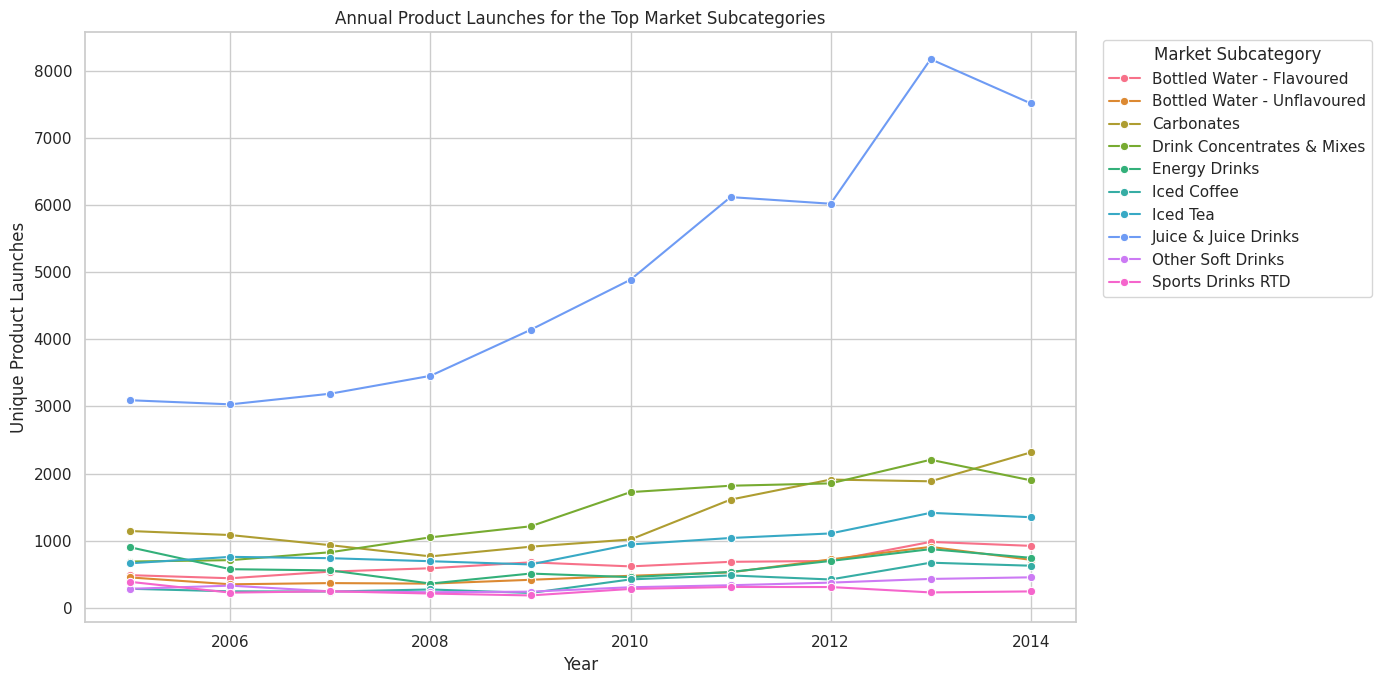

### Market subcategories with negative trends

,market_subcategory,slope_per_year,p_value,r_squared
0,Sports Drinks RTD,-3.34,0.64,0.03
1,Sports Others,-0.13,0.40,0.09


### Market subcategory with the highest number of unique flavors

,market_subcategory,unique_flavors
0,Juice & Juice Drinks,676
1,Drink Concentrates & Mixes,663
2,Carbonates,429
3,Other Soft Drinks,425
4,Iced Tea,411
5,Bottled Water - Flavoured,404
6,Energy Drinks,308
7,Iced Coffee,216
8,Sports Drinks RTD,175
9,Sports Powders,70


In [18]:
launches_by_year_subcategory = (
    product_df.dropna(subset=['year'])
    .groupby(['year', 'market_subcategory'])['id']
    .nunique()
    .reset_index(name='launches')
)

top_subcategories = (
    launches_by_year_subcategory.groupby('market_subcategory')['launches']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plot_data = launches_by_year_subcategory[launches_by_year_subcategory['market_subcategory'].isin(top_subcategories)]
if not plot_data.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=plot_data, x='year', y='launches', hue='market_subcategory', marker='o')
    plt.title('Annual Product Launches for the Top Market Subcategories')
    plt.xlabel('Year')
    plt.ylabel('Unique Product Launches')
    plt.legend(title='Market Subcategory', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('No annual market subcategory trend data is available for plotting.')

trend_matrix = launches_by_year_subcategory.pivot(index='year', columns='market_subcategory', values='launches').fillna(0)
trend_records = []
for subcategory in trend_matrix.columns:
    series = trend_matrix[subcategory]
    slope, intercept, r_value, p_value, std_err = linregress(trend_matrix.index.astype(float), series.values)
    trend_records.append({
        'market_subcategory': subcategory,
        'slope_per_year': slope,
        'p_value': p_value,
        'r_squared': r_value ** 2
    })

trend_results = pd.DataFrame(trend_records).sort_values('slope_per_year')
negative_trends = trend_results[trend_results['slope_per_year'] < 0].reset_index(drop=True)

subcategory_flavor_diversity = (
    flavor_long_df.groupby('market_subcategory')['flavor_clean']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name='unique_flavors')
)

display(Markdown('### Market subcategories with negative trends'))
display(negative_trends.head(15))

display(Markdown('### Market subcategory with the highest number of unique flavors'))
display(subcategory_flavor_diversity.head(10))

## Flavor Group Analysis

The exploded flavor dataset is merged with the flavor classification lookup to map each flavor to a broader flavor group. This makes it possible to analyze launches related to the `Fruit` flavor group over time, especially at a quarterly level.

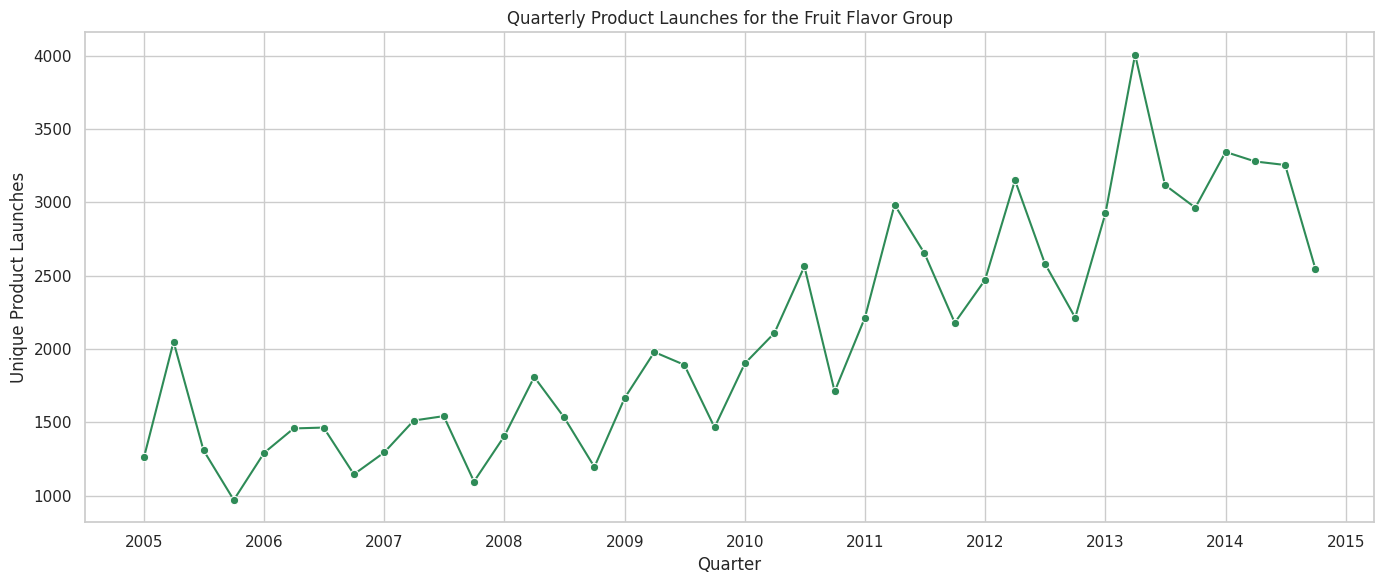

,id,market_subcategory,flavor_clean,flavor_group,quarter
0,1,Other Soft Drinks,"Herbs, not specified",Herbs,2005Q1
1,1,Other Soft Drinks,"Fruit, not specified",Fruit,2005Q1
2,2,Carbonates,"Fruit, not specified",Fruit,2005Q1
3,3,Juice & Juice Drinks,Lemon,Fruit,2005Q1
4,3,Juice & Juice Drinks,Honey,Brown Flavors,2005Q1
5,3,Juice & Juice Drinks,Ginger,Spices & Seeds,2005Q1
6,4,Juice & Juice Drinks,Mango,Fruit,2005Q1
7,4,Juice & Juice Drinks,Passion Fruit,Fruit,2005Q1
8,5,Juice & Juice Drinks,Mango,Fruit,2005Q1
9,6,Juice & Juice Drinks,"Fruit, not specified",Fruit,2005Q1


Fruit-mapped launch records: 83504


In [19]:
flavor_lookup = flavor_map_df[['flavor_group', 'flavor', 'flavor_key']].dropna(subset=['flavor_key']).drop_duplicates('flavor_key').copy()
flavor_enriched_df = flavor_long_df.merge(flavor_lookup, on='flavor_key', how='left', suffixes=('', '_mapped'))

fruit_launches = flavor_enriched_df[flavor_enriched_df['flavor_group'].eq('Fruit')].copy()
fruit_launches_quarterly = (
    fruit_launches.dropna(subset=['quarter'])
    .groupby('quarter')['id']
    .nunique()
    .reset_index(name='launches')
)
fruit_launches_quarterly['quarter_start'] = fruit_launches_quarterly['quarter'].dt.to_timestamp()

if not fruit_launches_quarterly.empty:
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=fruit_launches_quarterly, x='quarter_start', y='launches', marker='o', color='#2E8B57')
    plt.title('Quarterly Product Launches for the Fruit Flavor Group')
    plt.xlabel('Quarter')
    plt.ylabel('Unique Product Launches')
    plt.tight_layout()
    plt.show()
else:
    print('No quarterly launches were mapped to the Fruit flavor group.')

display(flavor_enriched_df[['id', 'market_subcategory', 'flavor_clean', 'flavor_group', 'quarter']].head(20))
print('Fruit-mapped launch records:', fruit_launches['id'].nunique())

## Positioning Analysis

The `positioning` column can contain multiple values for the same launch. The notebook therefore splits the field into separate rows, normalizes the text, and joins it with the positioning mapping table. The resulting structure is used to evaluate the launch distribution for `Convenience` and `Ethical` positioning groups.

,positioning_group,positioning_subcategory,launches
0,Convenience,Convenience - Consumption,58105
1,Convenience,Convenience - Easy-to-Prepare,11233
2,Convenience,Convenience - Packaging,9950
4,Convenience,Convenience - Time Saving,838
3,Convenience,Convenience - Ready Prepared,639
9,Ethical,Ethical - Packaging,18114
6,Ethical,Ethical - Environment,1674
7,Ethical,Ethical - Human,1221
5,Ethical,Ethical - Animal/Fish & Bird,107
8,Ethical,Ethical - Not Specific,26


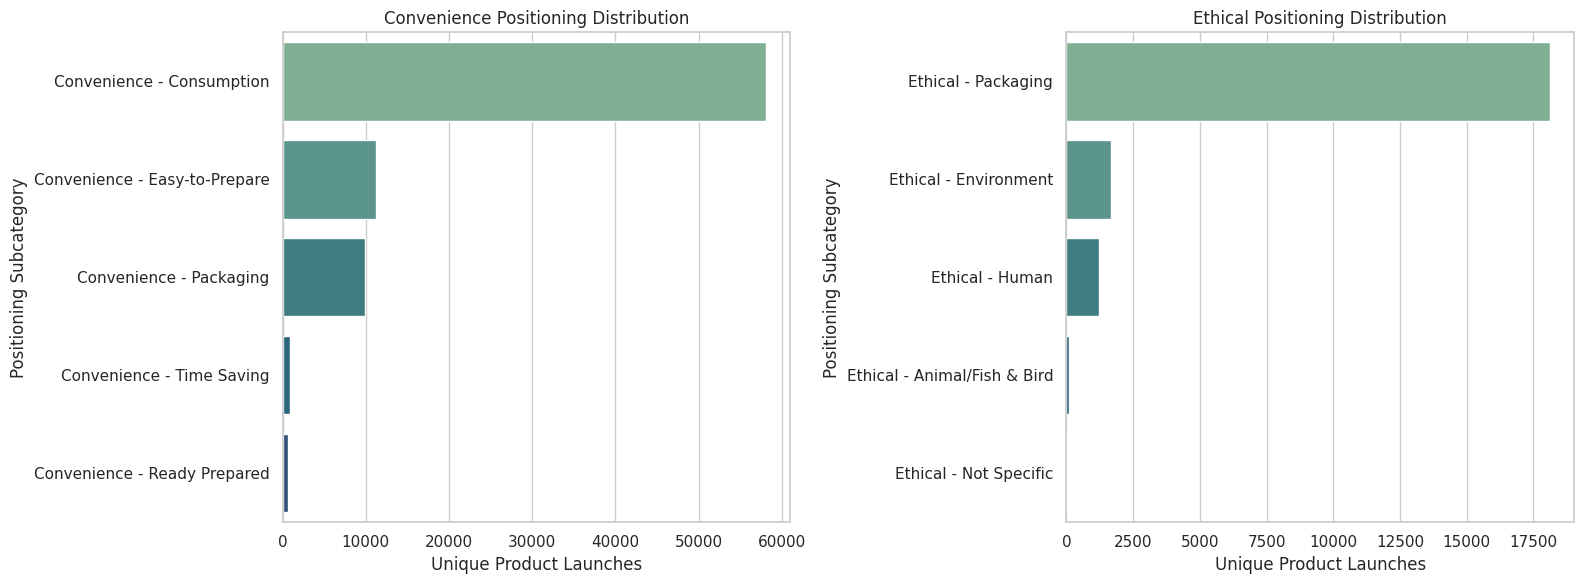

In [20]:
positioning_keys = set(positioning_map_df['positioning_key'].dropna())
positioning_long_df = product_df.copy()
positioning_long_df['positioning_value'] = positioning_long_df['positioning'].apply(lambda value: split_positioning(value, positioning_keys))
positioning_long_df = positioning_long_df.explode('positioning_value', ignore_index=True)
positioning_long_df['positioning_value'] = positioning_long_df['positioning_value'].apply(normalize_text)
positioning_long_df['positioning_key'] = positioning_long_df['positioning_value'].apply(normalize_key)
positioning_long_df = positioning_long_df.dropna(subset=['positioning_value']).drop_duplicates(['id', 'positioning_value']).copy()

positioning_lookup = positioning_map_df[['positioning_group', 'positioning_subcategory', 'positioning_key']].dropna(subset=['positioning_key']).drop_duplicates('positioning_key').copy()
positioning_enriched_df = positioning_long_df.merge(positioning_lookup, on='positioning_key', how='left')

selected_groups = ['Convenience', 'Ethical']
selected_positioning_summary = (
    positioning_enriched_df[positioning_enriched_df['positioning_group'].isin(selected_groups)]
    .groupby(['positioning_group', 'positioning_subcategory'])['id']
    .nunique()
    .reset_index(name='launches')
    .sort_values(['positioning_group', 'launches'], ascending=[True, False])
)

display(selected_positioning_summary)

if not selected_positioning_summary.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
    for axis, group_name in zip(axes, selected_groups):
        chart_data = selected_positioning_summary[selected_positioning_summary['positioning_group'] == group_name]
        if not chart_data.empty:
            sns.barplot(data=chart_data, x='launches', y='positioning_subcategory', ax=axis, palette='crest')
        axis.set_title(f'{group_name} Positioning Distribution')
        axis.set_xlabel('Unique Product Launches')
        axis.set_ylabel('Positioning Subcategory')
    plt.tight_layout()
    plt.show()
else:
    print('No mapped Convenience or Ethical positioning records were available for plotting.')

## Data Aggregation

This section generates product-launch summaries at monthly, quarterly, and yearly levels. These tables support both dashboard-style reporting and export to Excel for downstream pivot-table analysis.

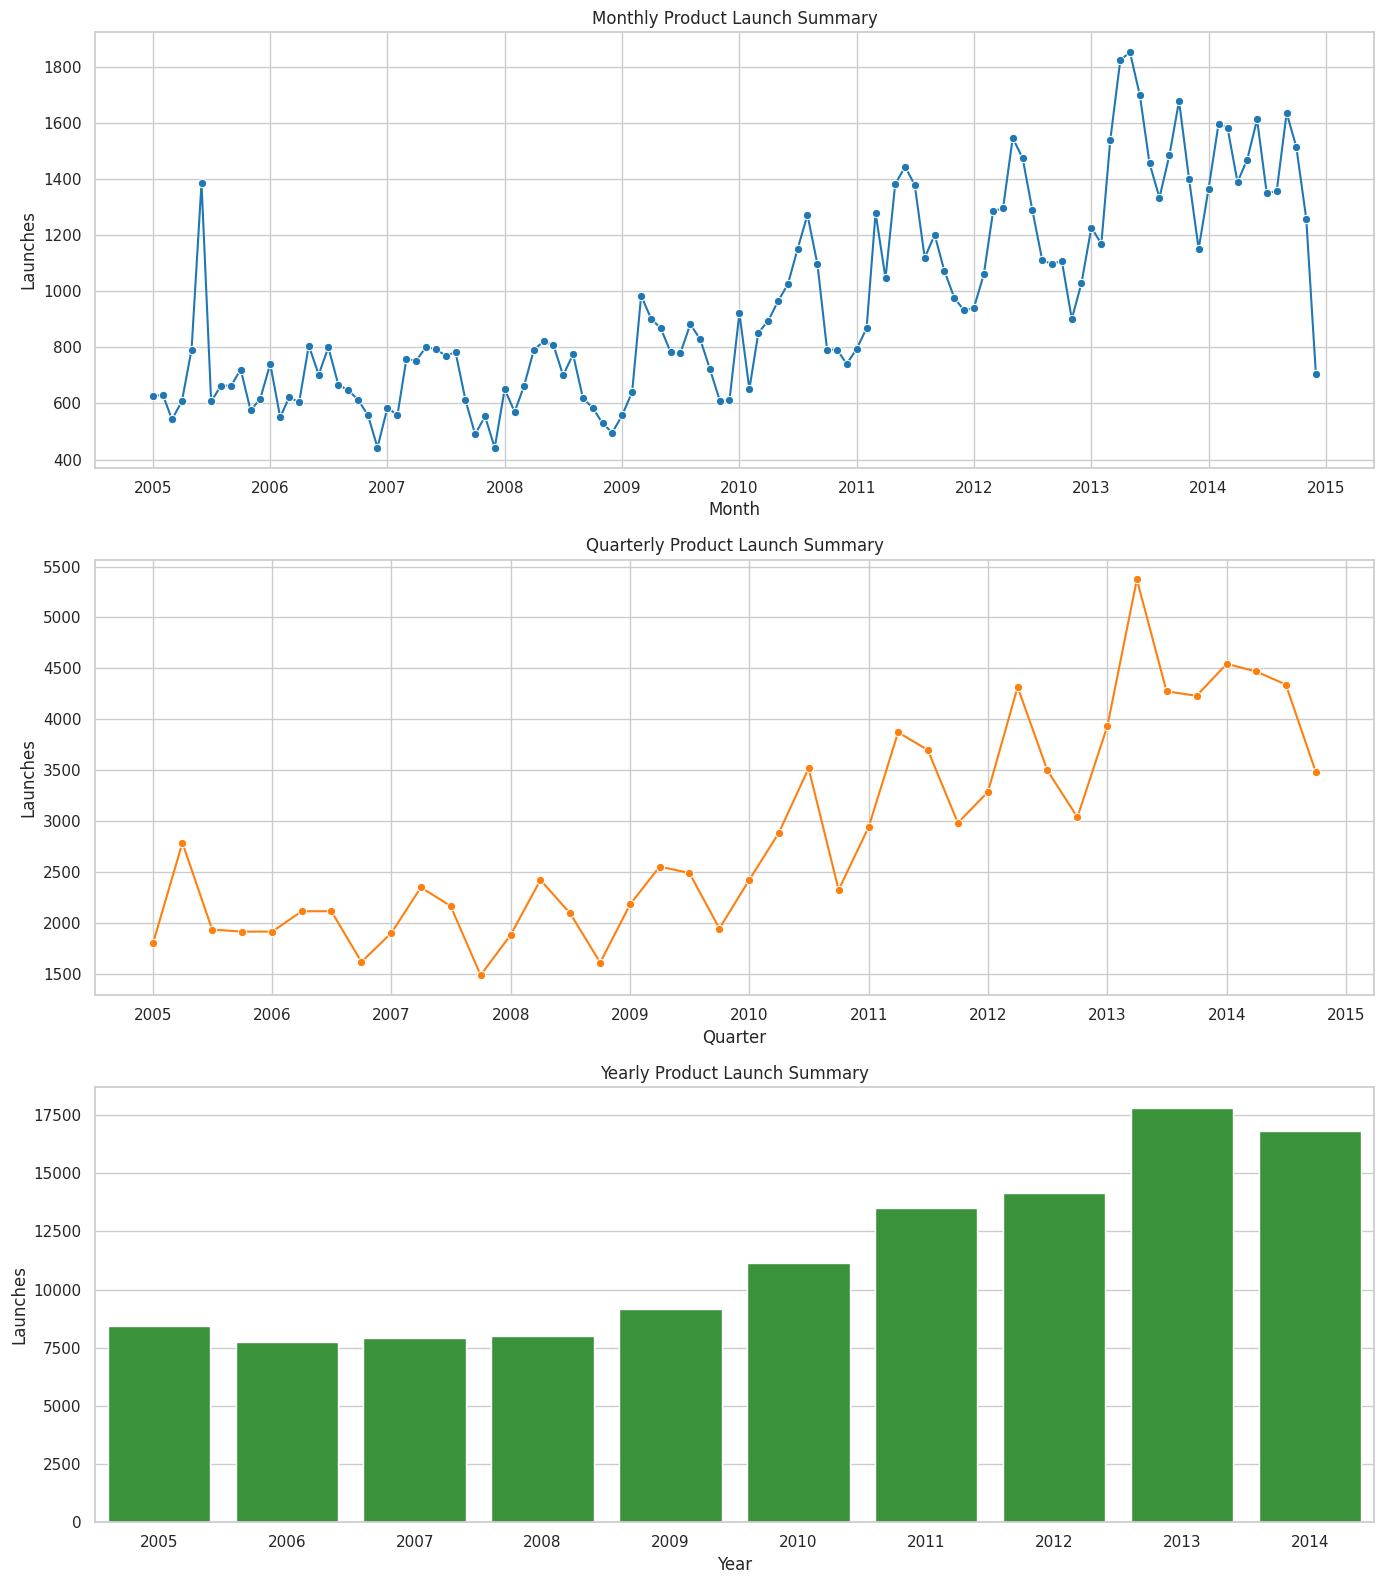

,year_month,launches,period_start
0,2005-01,627,2005-01-01
1,2005-02,630,2005-02-01
2,2005-03,543,2005-03-01
3,2005-04,608,2005-04-01
4,2005-05,792,2005-05-01


,quarter,launches,period_start
0,2005Q1,1800,2005-01-01
1,2005Q2,2786,2005-04-01
2,2005Q3,1934,2005-07-01
3,2005Q4,1913,2005-10-01
4,2006Q1,1914,2006-01-01


,year,launches
0,2005,8433
1,2006,7757
2,2007,7900
3,2008,8005
4,2009,9169


In [21]:
monthly_summary = (
    product_df.dropna(subset=['year_month'])
    .groupby('year_month')['id']
    .nunique()
    .reset_index(name='launches')
)
monthly_summary['period_start'] = monthly_summary['year_month'].dt.to_timestamp()
monthly_summary['year_month'] = monthly_summary['year_month'].astype(str)

quarterly_summary = (
    product_df.dropna(subset=['quarter'])
    .groupby('quarter')['id']
    .nunique()
    .reset_index(name='launches')
)
quarterly_summary['period_start'] = quarterly_summary['quarter'].dt.to_timestamp()
quarterly_summary['quarter'] = quarterly_summary['quarter'].astype(str)

yearly_summary = (
    product_df.dropna(subset=['year'])
    .groupby('year')['id']
    .nunique()
    .reset_index(name='launches')
)

if not monthly_summary.empty or not quarterly_summary.empty or not yearly_summary.empty:
    fig, axes = plt.subplots(3, 1, figsize=(14, 16))
    if not monthly_summary.empty:
        sns.lineplot(data=monthly_summary, x='period_start', y='launches', marker='o', ax=axes[0], color='#1f77b4')
    axes[0].set_title('Monthly Product Launch Summary')
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Launches')

    if not quarterly_summary.empty:
        sns.lineplot(data=quarterly_summary, x='period_start', y='launches', marker='o', ax=axes[1], color='#ff7f0e')
    axes[1].set_title('Quarterly Product Launch Summary')
    axes[1].set_xlabel('Quarter')
    axes[1].set_ylabel('Launches')

    if not yearly_summary.empty:
        sns.barplot(data=yearly_summary, x='year', y='launches', ax=axes[2], color='#2ca02c')
    axes[2].set_title('Yearly Product Launch Summary')
    axes[2].set_xlabel('Year')
    axes[2].set_ylabel('Launches')

    plt.tight_layout()
    plt.show()
else:
    print('No monthly, quarterly, or yearly summaries were available for plotting.')

display(monthly_summary.head())
display(quarterly_summary.head())
display(yearly_summary.head())

write_excel_safely(
    OUTPUT_DIR / 'market_analysis_summaries.xlsx',
    {
        'Monthly Summary': monthly_summary,
        'Quarterly Summary': quarterly_summary,
        'Yearly Summary': yearly_summary
    }
)

## Filtering, Subsetting, and Hypothesis Testing

A targeted subset is extracted for Canada, 2013, Energy Drinks, and Ethical Packaging. The section also identifies the top five flavors across countries in 2013 and performs hypothesis testing on the top five positioning groups in the same year using monthly launch counts as the comparison unit.

In [22]:
ethical_packaging_ids = set(
    positioning_enriched_df[positioning_enriched_df['positioning_subcategory'].eq('Ethical - Packaging')]['id']
)

product_df['has_ethical_packaging'] = product_df['id'].isin(ethical_packaging_ids)

filtered_canada_2013 = product_df[
    product_df['country_key'].eq('canada')
    & product_df['year'].eq(2013)
    & product_df['market_subcategory_key'].eq('energy drinks')
    & product_df['has_ethical_packaging']
].copy()

display(Markdown('### Filtered dataset: Canada, 2013, Energy Drinks, Ethical Packaging'))
display(filtered_canada_2013)
print('Filtered row count:', len(filtered_canada_2013))

top_flavors_2013 = (
    flavor_long_df[flavor_long_df['year'].eq(2013)]
    .groupby('flavor_clean')
    .agg(countries=('country', 'nunique'), launches=('id', 'nunique'))
    .sort_values(['countries', 'launches', 'flavor_clean'], ascending=[False, False, True])
    .head(5)
    .reset_index()
)

display(Markdown('### Top 5 unique flavors across countries in 2013'))
display(top_flavors_2013)

positioning_2013 = positioning_enriched_df[positioning_enriched_df['year'].eq(2013)].copy()
top_positioning_groups_2013 = (
    positioning_2013.dropna(subset=['positioning_group'])
    .groupby('positioning_group')['id']
    .nunique()
    .sort_values(ascending=False)
    .head(5)
)

display(Markdown('### Top 5 positioning groups in 2013'))
display(top_positioning_groups_2013.rename('launches').reset_index())

monthly_positioning_counts = (
    positioning_2013[positioning_2013['positioning_group'].isin(top_positioning_groups_2013.index)]
    .groupby(['month', 'positioning_group'])['id']
    .nunique()
    .reset_index(name='launches')
)

monthly_positioning_matrix = (
    monthly_positioning_counts
    .pivot(index='month', columns='positioning_group', values='launches')
    .reindex(index=range(1, 13), fill_value=0)
    .fillna(0)
)

anova_input = [monthly_positioning_matrix[group].values for group in top_positioning_groups_2013.index]
anova_result = stats.f_oneway(*anova_input) if len(anova_input) >= 2 else None

pairwise_records = []
group_names = list(top_positioning_groups_2013.index)
raw_p_values = []

for left_index in range(len(group_names)):
    for right_index in range(left_index + 1, len(group_names)):
        left_group = group_names[left_index]
        right_group = group_names[right_index]
        test_stat, p_value = stats.ttest_ind(
            monthly_positioning_matrix[left_group].values,
            monthly_positioning_matrix[right_group].values,
            equal_var=False
        )
        raw_p_values.append(p_value)
        pairwise_records.append({
            'group_a': left_group,
            'group_b': right_group,
            't_statistic': test_stat,
            'raw_p_value': p_value
        })

pairwise_results = pd.DataFrame(pairwise_records)
if not pairwise_results.empty:
    pairwise_results['adjusted_p_value'] = holm_correction(pairwise_results['raw_p_value'])
    pairwise_results['significant_at_5pct'] = pairwise_results['adjusted_p_value'] < 0.05

if anova_result is not None:
    display(Markdown(
        f"### ANOVA result\nF-statistic: **{anova_result.statistic:.4f}**\nP-value: **{anova_result.pvalue:.6f}**"
    ))

display(Markdown('### Pairwise t-tests with Holm correction'))
if not pairwise_results.empty:
    display(pairwise_results)
else:
    print('Not enough positioning-group pairs were available for pairwise testing.')

if anova_result is not None:
    if anova_result.pvalue < 0.05:
        print('Conclusion: At least one of the top positioning groups has a significantly different monthly launch pattern at the 5% level.')
    else:
        print('Conclusion: The ANOVA test does not find a statistically significant difference among the top positioning groups at the 5% level.')

### Filtered dataset: Canada, 2013, Energy Drinks, Ethical Packaging

,market_subcategory,id,eventdate,country,positioning,region,flavor,year,month,month_name,quarter,year_month,country_key,market_subcategory_key,has_ethical_packaging
82404,Energy Drinks,82405,2013-11-01,Canada,"Organic, Energy/Alertness, Ethical - Human, Et...",North America,"Berry, Not specified; Tea, Green; Tea, Mate",2013,11,November,2013Q4,2013-11,canada,energy drinks,True
82405,Energy Drinks,82406,2013-11-01,Canada,"Brain Health, Energy/Alertness, Ethical - Pack...",North America,"Citrus, Not Specified",2013,11,November,2013Q4,2013-11,canada,energy drinks,True
82439,Energy Drinks,82440,2013-11-01,Canada,"Brain Health, Energy/Alertness, Ethical - Pack...",North America,"Cherry, Not Specified",2013,11,November,2013Q4,2013-11,canada,energy drinks,True
82440,Energy Drinks,82441,2013-11-01,Canada,"Brain Health, Energy/Alertness, Ethical - Pack...",North America,"Berry, Mixed",2013,11,November,2013Q4,2013-11,canada,energy drinks,True


Filtered row count: 4


### Top 5 unique flavors across countries in 2013

,flavor_clean,countries,launches
0,"Apple, Red",80,1790
1,Pineapple,79,799
2,"Orange, Not specified",78,1890
3,Unflavored,76,1493
4,Peach,75,764


...

,positioning_group,launches
0,Convenience,12760
1,Health (Passive),9741
2,Juice,6320
3,Ethical,5873
4,Choice,2943


### ANOVA result
F-statistic: **76.8719**
P-value: **0.000000**

### Pairwise t-tests with Holm correction

,group_a,group_b,t_statistic,raw_p_value,adjusted_p_value,significant_at_5pct
0,Convenience,Health (Passive),4.09,0.00,0.00,True
1,Convenience,Juice,9.35,0.00,0.00,True
2,Convenience,Ethical,9.15,0.00,0.00,True
3,Convenience,Choice,16.46,0.00,0.00,True
4,Health (Passive),Juice,5.80,0.00,0.00,True
5,Health (Passive),Ethical,5.83,0.00,0.00,True
6,Health (Passive),Choice,14.20,0.00,0.00,True
7,Juice,Ethical,0.73,0.47,0.47,False
8,Juice,Choice,8.44,0.00,0.00,True
9,Ethical,Choice,5.84,0.00,0.00,True


Conclusion: At least one of the top positioning groups has a significantly different monthly launch pattern at the 5% level.


## Business Insights and Export Outputs

The final section translates the analysis into concise business findings and exports the cleaned deliverables required for reporting and pivot-table work.

In [23]:
most_common_flavors = (
    flavor_long_df.groupby('flavor_clean')['id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_declining_subcategory = negative_trends.iloc[0] if not negative_trends.empty else None
fruit_recent_trend = fruit_launches_quarterly.sort_values('quarter_start').tail(8)
fruit_trend_direction = (fruit_recent_trend['launches'].iloc[-1] - fruit_recent_trend['launches'].iloc[0]) if len(fruit_recent_trend) >= 2 else np.nan
ethical_launch_share = product_df['has_ethical_packaging'].mean() * 100

insight_lines = ['### Key business insights']
if not most_common_flavors.empty:
    insight_lines.append(
        f'- The most common flavors by unique launches are led by **{most_common_flavors.index[0]}** and other high-frequency mainstream tastes.'
    )
if not subcategory_flavor_diversity.empty:
    insight_lines.append(
        f'- The subcategory with the widest flavor variety is **{subcategory_flavor_diversity.iloc[0, 0]}**, with **{subcategory_flavor_diversity.iloc[0, 1]}** unique cleaned flavors.'
    )
insight_lines.append(
    f'- Ethical Packaging appears in **{ethical_launch_share:.2f}%** of all launches, indicating a measurable sustainability-related positioning presence.'
)

if top_declining_subcategory is not None:
    declining_name = top_declining_subcategory['market_subcategory']
    declining_slope = top_declining_subcategory['slope_per_year']
    insight_lines.append(
        f'- The steepest negative annual launch trend is observed in **{declining_name}** with a slope of **{declining_slope:.2f} launches per year**.'
    )

if not np.isnan(fruit_trend_direction):
    direction = 'upward' if fruit_trend_direction > 0 else 'downward' if fruit_trend_direction < 0 else 'flat'
    insight_lines.append(
        f'- The recent quarterly Fruit flavor-group trend is **{direction}**, based on the last eight observed quarters.'
    )

display(Markdown('\n'.join(insight_lines)))

cleaned_export_df = product_df.copy()
processed_flavor_export_df = flavor_enriched_df.copy()

cleaned_export_df.to_csv(OUTPUT_DIR / 'product_launch_cleaned.csv', index=False)
processed_flavor_export_df.to_csv(OUTPUT_DIR / 'processed_flavor_dataset.csv', index=False)
monthly_summary.to_csv(OUTPUT_DIR / 'monthly_launch_summary.csv', index=False)
quarterly_summary.to_csv(OUTPUT_DIR / 'quarterly_launch_summary.csv', index=False)
yearly_summary.to_csv(OUTPUT_DIR / 'yearly_launch_summary.csv', index=False)
filtered_canada_2013.to_csv(OUTPUT_DIR / 'canada_2013_energy_drinks_ethical_packaging.csv', index=False)

display(Markdown(
    '### Exported files\n'
    '- outputs/product_launch_cleaned.csv\n'
    '- outputs/processed_flavor_dataset.csv\n'
    '- outputs/monthly_launch_summary.csv\n'
    '- outputs/quarterly_launch_summary.csv\n'
    '- outputs/yearly_launch_summary.csv\n'
    '- outputs/canada_2013_energy_drinks_ethical_packaging.csv\n'
    '- outputs/market_analysis_summaries.xlsx'
))

display(Markdown('### Conclusion\nThe notebook delivers a complete end-to-end market analysis workflow, from raw-data preparation to interpretable trend analysis, statistical testing, and export-ready outputs.'))

### Key business insights
- The most common flavors by unique launches are led by **Unflavored** and other high-frequency mainstream tastes.
- The subcategory with the widest flavor variety is **Juice & Juice Drinks**, with **676** unique cleaned flavors.
- Ethical Packaging appears in **15.79%** of all launches, indicating a measurable sustainability-related positioning presence.
- The steepest negative annual launch trend is observed in **Sports Drinks RTD** with a slope of **-3.34 launches per year**.
- The recent quarterly Fruit flavor-group trend is **downward**, based on the last eight observed quarters.

### Exported files
- outputs/product_launch_cleaned.csv
- outputs/processed_flavor_dataset.csv
- outputs/monthly_launch_summary.csv
- outputs/quarterly_launch_summary.csv
- outputs/yearly_launch_summary.csv
- outputs/canada_2013_energy_drinks_ethical_packaging.csv
- outputs/market_analysis_summaries.xlsx

### Conclusion
The notebook delivers a complete end-to-end market analysis workflow, from raw-data preparation to interpretable trend analysis, statistical testing, and export-ready outputs.